<a href="https://colab.research.google.com/github/KaueOPG/DCC008---Calculo-Numerico/blob/main/Trabalho3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#3° Exercício Computacional - Zeros de funções reais


#Grupo:
1 - Kauê Oliveira Paraízo Garcia - 202265517B

2 - João Pedro Barbosa Coelho - 202369012D

#Pré-requisitos

As seguintes bibliotecas foram instaladas e importadas:

In [ ]:
import numpy as np
import math
import sympy as sym
import matplotlib.pyplot

As seguintes funções foram implementadas:

Método da bissecção:

Sabendo que, dado um interválo [a, b] e que sabe-se que existe raizes dado que f(a) x f(b) < 0, a idéia fundamental consiste em subdividir o intervalo ao meio a cada iteração e seleciona o subintervalo que obedeça a equação vista.




In [ ]:
def bisection(f, a, b, tolerance, n_max):
  if(f(a)* f(b) > 0):
    print('Intervalo Inadequado')
  else:
    n=0
    error=np.zeros(n_max)
    for k in range(n_max):
      n=n+1
      x= (a+b)/2
      error[k]= abs(f(x))
      if error[k]<tolerance:
        break
      if f(x)*f(a)<0:
        b=x
      else:
        a=x
    return x, error, n

Método da falsa posição:

Nesse método consiste em a aproximar um
ponto xk escolhido como sendo o zero da reta que passa pelos
pontos (ak, f(ak)) e (bk, f(bk)), ou seja, a cada iteração o método encontra um intervalo que contém a raiz e continua o processo de busca nesse intervalo.

In [ ]:
def regulaFalsi(f, a, b, tolerance, n_max):
  if(f(a)* f(b) > 0):
    print('Intervalo Inadequado')
  else:
    n=0
    error=np.zeros(n_max)
    for k in range(n_max):
      n=n+1
      x= (a*f(b)-b*f(a))/(f(b)-f(a))
      error[k]= abs(f(x))
      if error[k]<tolerance:
        break
      if f(x)*f(a)<0:
        b=x
      else:
        a=x
    return x, error, n

Método do ponto fixo:

Para encontrar a raiz da equação onde f(x) = 0 é uma função contínua no intervalo [a, b], declararemos uma função phi, tal qual x = φ(x), em que a solução dela também seja solução da primeira. Ademais, vale resaltar que existe uma solução única no no intervalo se o módulo devf(a) x f(b) for menor que uma constante M < 1, ou seja, as derivadas em a e b tem que ser < 1.

In [ ]:
def FixedPoint(t, f, phi, a, b, tolerance, n_max):
  dphi= sym.diff(phi,t)
  if abs(dphi.subs(t,a))>1 or abs(dphi.subs(t,b))>1:
    print('Intervalo Inadequado')
  else:
    n=0
    x=(a+b)/2
    error=np.zeros(n_max)
    for k in range(n_max):
      n=n+1
      x= phi.subs(t,x)
      error[k]=abs(f.subs(t, x))
      if error[k]<tolerance:
        break
    return x, error, n

Método de Newton:

A idéia do método de Newton, quando visto no método do ponto fixo, é
tentar garantir e acelerar a convergência desse escolhendo a
função de iteração φ(x) de tal forma que sua derivada seja igual a zero.

In [ ]:
def Newton(t, f, x, tolerance, n_max):
  n=0
  error=np.zeros(n_max)
  F= sym.diff(f,t)
  for k in range(n_max):
    n=n+1
    x = sym.N(x-f.subs(t,x)/F.subs(t,x))
    error[k]= abs(f.subs(t,x))
    if error[k]<tolerance:
      break
  return x, error, n

Método da Secante:

Esse método consiste em modificar o método passado de tal forma que a derivada de f seja dada pelo pelo quociente das diferenças $\frac{f(xk) − f(xk−1)}{xk − xk−1}$.

In [ ]:
def Secant(f, x0, x1, tolerance, n_max):
  n=0
  error=np.zeros(n_max)
  for k in range(n_max):
    n=n+1
    x = (f(x1)*x0-f(x0)*x1)/(f(x1)-f(x0))
    error[k]= abs(f(x))
    if error[k]<tolerance:
      break
    x0=x1
    x1=x
  return x, error, n

#Testes

Para testar a implementação, os seguintes problemas foram utilizados considerando uma tolerância de $10^{−8}$:

a) $f(x) = ex + 2−x + 2 cos(x) − 6 = 0$ para $x ∈ [1, 2]$.

b) $g(x) = 2x cos(2x) − (x − 2)^2 = 0$ para $x ∈ [2, 3]$ e $x ∈ [3, 4]$.

c) $h(x) = e^x − 3x^2 = 0$ para $x ∈ [0, 1]$ e $x ∈ [3, 5]$.

In [ ]:
# Declaração das funções

def f(x):
  return np.exp(x)+2**(-x)+2*np.cos(x)-6

def g(x):
  return 2*x*np.cos(2*x)-(x-2)**2

def h(x):
  return np.exp(x)-3*x**2

In [ ]:
# Cálculo das derivadas e funções phi

t=sym.symbols('t')

# Derivada de f
F=sym.exp(t)+2**(-t)+2*sym.cos(t)-6
print("f'(x):")
F

f'(x):


exp(t) + 2*cos(t) - 6 + 2**(-t)

In [ ]:
# Derivada de g
G=2*t*sym.cos(2*t)-(t-2)**2
print("g'(x):")
G

g'(x):


2*t*cos(2*t) - (t - 2)**2

In [ ]:
# Derivada de h
H=sym.exp(t)-3*t**2
print("h'(x):")
H

h'(x):


-3*t**2 + exp(t)

In [ ]:
# Phi de f
phi_F= sym.ln(6-2**(-t)-2*sym.cos(t))
phi_F

log(-2*cos(t) + 6 - 1/2**t)

In [ ]:
# Phi de g1
phi_G1= math.pi-1/2*sym.acos((t-2)**2/2/t)
phi_G1

3.14159265358979 - 0.5*acos((t - 2)**2/(2*t))

In [ ]:
# Phi de g2
phi_G2= math.pi+1/2*sym.acos((t-2)**2/2/t)
phi_G2

0.5*acos((t - 2)**2/(2*t)) + 3.14159265358979

In [ ]:
# Phi de h1
phi_H1= sym.exp(t/2)/np.sqrt(3)
phi_H1

0.577350269189626*exp(t/2)

In [ ]:
# Phi de h2
phi_H2= np.log(3)+2*sym.ln(t)
phi_H2

2*log(t) + 1.09861228866811

In [ ]:
# Declaração dos vetores n(numero de interações), x(resultado x para cada metodo) errror(conjunto de erros por método) e n(número final de interações) de cada função

n = np.zeros(10)
for i in range(10):
  n[i] = i + 1

xf = np.zeros(5)
xg1 = np.zeros(5)
xg2 = np.zeros(5)
xh1 = np.zeros(5)
xh2 = np.zeros(5)

errorf = [(range(35))]*5
errorg1 = [(range(35))]*5
errorg2 = [(range(35))]*5
errorh1 = [(range(35))]*5
errorh2 = [(range(35))]*5

nf = np.zeros(5)
ng1 = np.zeros(5)
ng2 = np.zeros(5)
nh1 = np.zeros(5)
nh2 = np.zeros(5)

Método da Bissecção:

In [ ]:
xf[0], errorf[0], nf[0] = bisection(f, 1, 2, 10**(-8), 10)

xg1[0], errorg1[0], ng1[0] = bisection(g, 2, 3, 10**(-8), 10)

xg2[0], errorg2[0], ng2[0] = bisection(g, 3, 4, 10**(-8), 10)

xh1[0], errorh1[0], nh1[0] = bisection(h, 0, 1, 10**(-8), 10)

xh2[0], errorh2[0], nh2[0] = bisection(h, 3, 5, 10**(-8), 10)

Método da Falsa Posição

In [ ]:
xf[1], errorf[1], nf[1] = regulaFalsi(f, 1, 2, 10**(-8), 10)

xg1[1], errorg1[1], ng1[1] = regulaFalsi(g, 2, 3, 10**(-8), 10)

xg2[1], errorg2[1], ng2[1] = regulaFalsi(g, 3, 4, 10**(-8), 10)

xh1[1], errorh1[1], nh1[1] = regulaFalsi(h, 0, 1, 10**(-8), 10)

xh2[1], errorh2[1], nh2[1] = regulaFalsi(h, 3, 5, 10**(-8), 10)

Método do Ponto Fixo (Argumento Simbólico)

In [ ]:
xf[2], errorf[2], nf[2] = FixedPoint(t, F, phi_F, 1, 2, 10**(-8), 10)

xg1[2], errorg1[2], ng1[2] = FixedPoint(t, G, phi_G1, 2, 3, 10**(-8), 10)

xg2[2], errorg2[2], ng2[2] = FixedPoint(t, G, phi_G2, 3, 4, 10**(-8), 10)

xh1[2], errorh1[2], nh1[2] = FixedPoint(t, H, phi_H1, 0, 1, 10**(-8), 10)

xh2[2], errorh2[2], nh2[2] = FixedPoint(t, H, phi_H2, 3, 5, 10**(-8), 10)

Método de Newton (Argumento Simbólico)

In [ ]:
xf[3], errorf[3], nf[3] = Newton(t, F, 1.5, 10**(-8), 10)

xg1[3], errorg1[3], ng1[3] = Newton(t, G, 2.5, 10**(-8), 10)

xg2[3], errorg2[3], ng2[3] = Newton(t, G, 3.5, 10**(-8), 10)

xh1[3], errorh1[3], nh1[3] = Newton(t, H, 0.5, 10**(-8),10)

xh2[3], errorh2[3], nh2[3] = Newton(t, H, 3.9, 10**(-8), 10)

Método da Secante

In [ ]:
xf[4], errorf[4], nf[4] = Secant(f, 1, 2, 10**(-8), 10)

xg1[4], errorg1[4], ng1[4] = Secant(g, 2, 3, 10**(-8), 10)

xg2[4], errorg2[4], ng2[4] = Secant(g, 3, 4, 10**(-8), 10)

xh1[4], errorh1[4], nh1[4] = Secant(h, 0, 1, 10**(-8), 10)

xh2[4], errorh2[4], nh2[4] = Secant(h, 3, 5, 10**(-8), 10)

#Conclusão dos testes

Pode-se perceber que, com a análise dos gráficos abaixo, o método que tem a melhor performace, ou seja, chega em um resultado próximo com o menor número de interações na maioria dos casos, seria o método de Newton.

$f(x) = ex + 2−x + 2 cos(x) − 6 = 0$ para $x ∈ [1, 2]$:

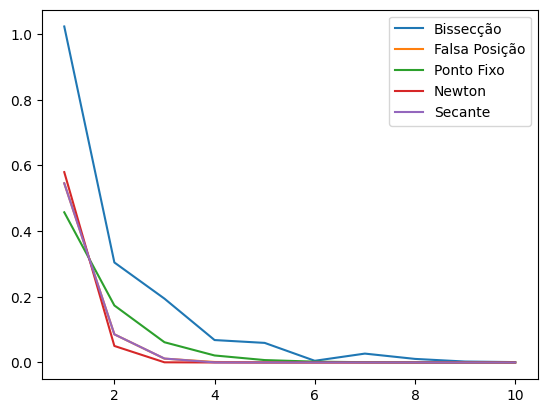

In [ ]:
matplotlib.pyplot.plot(n, errorf[0], label = 'Bissecção')
matplotlib.pyplot.plot(n, errorf[1], label = 'Falsa Posição')
matplotlib.pyplot.plot(n, errorf[2], label = 'Ponto Fixo')
matplotlib.pyplot.plot(n, errorf[3], label = 'Newton')
matplotlib.pyplot.plot(n, errorf[4], label = 'Secante')
matplotlib.pyplot.legend()
matplotlib.pyplot.show()

$g(x) = 2x cos(2x) − (x − 2)^2 = 0$ para $x ∈ [2, 3]$:

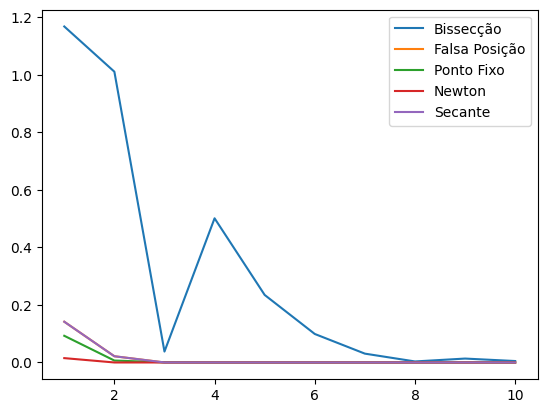

In [ ]:
matplotlib.pyplot.plot(n, errorg1[0], label = 'Bissecção')
matplotlib.pyplot.plot(n, errorg1[1], label = 'Falsa Posição')
matplotlib.pyplot.plot(n, errorg1[2], label = 'Ponto Fixo')
matplotlib.pyplot.plot(n, errorg1[3], label = 'Newton')
matplotlib.pyplot.plot(n, errorg1[4], label = 'Secante')
matplotlib.pyplot.legend()
matplotlib.pyplot.show()

$g(x) = 2x cos(2x) − (x − 2)^2 = 0$ para $x ∈ [3, 4]$:

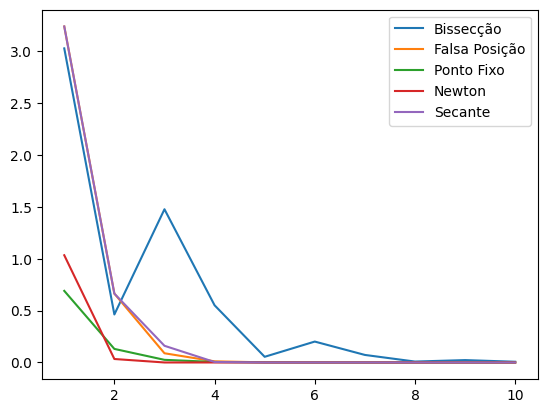

In [ ]:
matplotlib.pyplot.plot(n, errorg2[0], label = 'Bissecção')
matplotlib.pyplot.plot(n, errorg2[1], label = 'Falsa Posição')
matplotlib.pyplot.plot(n, errorg2[2], label = 'Ponto Fixo')
matplotlib.pyplot.plot(n, errorg2[3], label = 'Newton')
matplotlib.pyplot.plot(n, errorg2[4], label = 'Secante')
matplotlib.pyplot.legend()
matplotlib.pyplot.show()

$h(x) = e^x − 3x^2 = 0$ para $x ∈ [0, 1]$:

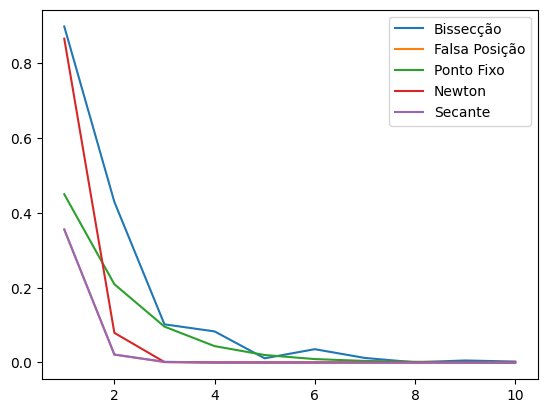

In [ ]:
matplotlib.pyplot.plot(n, errorh1[0], label = 'Bissecção')
matplotlib.pyplot.plot(n, errorh1[1], label = 'Falsa Posição')
matplotlib.pyplot.plot(n, errorh1[2], label = 'Ponto Fixo')
matplotlib.pyplot.plot(n, errorh1[3], label = 'Newton')
matplotlib.pyplot.plot(n, errorh1[4], label = 'Secante')
matplotlib.pyplot.legend()
matplotlib.pyplot.show()

$h(x) = e^x − 3x^2 = 0$ para $x ∈ [3, 5]$:

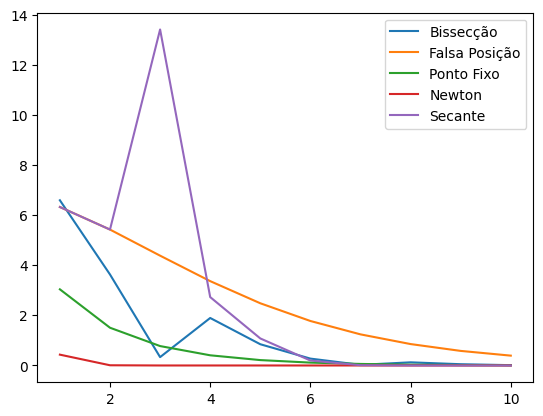

In [ ]:
matplotlib.pyplot.plot(n, errorh2[0], label = 'Bissecção')
matplotlib.pyplot.plot(n, errorh2[1], label = 'Falsa Posição')
matplotlib.pyplot.plot(n, errorh2[2], label = 'Ponto Fixo')
matplotlib.pyplot.plot(n, errorh2[3], label = 'Newton')
matplotlib.pyplot.plot(n, errorh2[4], label = 'Secante')
matplotlib.pyplot.legend()
matplotlib.pyplot.show()

#Problemas Práticos:


**Questão 1:**



In [ ]:
# Declaração de A
y= 750000-1500/t*((1+t)**240-1)
print('A:')
y

a) A taxa de juros mínima em que essa quantia pode ser investida é aproximadamente de 0,0056 %, como pode ser visto abaixo:

In [ ]:
x,error,n = Newton(t, y, 0.01, 0.0001, 20)
print('A taxa seria de ',x, "%")

b)  Profissional não conseguiria alcançar seu objetivo(RS 750.000,00) no tempo desejado(20 anos), sendo no final um valor a ser obtido de RS 359.985,44, uma diferença de RS -390014,55, como pode ser visto abaixo:

In [ ]:
# Cálculo do valor final
A=0
for n in range(240):
  A= A*(1+np.sin(n/2+1)/10000)+1500
print('O valor final seria de ', A)
print('A diferença é de RS ', 750000 - A)

**Questão 2:**

a) A quantidade A a ser injetada para que essa concentração máxima
segura seja alcançada é de 3,00 mg/ml e será alcançada em 1 hora, aproximadamente.

In [ ]:
# Declaração de C
c= t*sym.exp(-t/3)
print("C:")
c

In [ ]:
# Obtendo a derivada de C

d= sym.diff(c)
print("C':")
d

In [ ]:
# Cálculando a concentração

x,error,n = Newton(t, d, 0.01, 0.0001, 10)
print("A quantidade é de  ", x)

In [ ]:
# Cálculando o tempo

A2= 1/c.subs(t,x)
print('O tempo será de ', A2)

O tempo será de  0.906093942819719


b) A segunda injenção deve ser injetada 18 minutos após a primeira.

In [ ]:
# Obetendo o tempo

x,error,n = Newton(t, c-0.25/A2, 0.01, 0.0001, 10)
print('O tempo é de', 60*x)